# Introduction

This project investigates the application of supervised machine learning techniques to a real-world classification problem using the FARS (Fatality Analysis Reporting System) dataset. The aim is to design, evaluate, and compare multiple machine learning pipelines for predicting injury severity in US road traffic accidents.

The project follows a complete machine learning workflow including:

* Exploratory Data Analysis (EDA)

* Data preprocessing

* Pipeline design

* Model training and evaluation

* Hyperparameter tuning

* Comparative analysis and discussion

All experiments are conducted using cross validation to ensure robustness and model performance is primarily assessed using the macro averaged F1 score, which is appropriate for imbalanced multi class classification problems.


# Dataset Description

The FARS dataset contains over 100,000 observations at the person level and includes a mixture of numerical and categorical variables describing accident circumstances and individual characteristics. The target variable is:

**INJURY_SEVERITY** (categorical variable)

Key feature groups include:

* Demographic information (e.g. age, sex)

* Vehicle safety information (e.g. restraint system use, airbag deployment)

* Alcohol and drug involvement

* Seating position and person type

In [ ]:
pip install --upgrade numpy pandas scikit-learn ydata-profiling


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pan

In [ ]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.feature_selection import SelectFromModel
from ydata_profiling import ProfileReport
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Exploratory Data Analysis (EDA)

Exploratory analysis was conducted prior to preprocessing to understand the structure and quality of the dataset.

Key EDA steps included:

* Inspecting data types and feature distributions

* Checking class distribution of the target variable

* Identifying duplicate records

* Detecting missing values

* Checking the distribution of numerical features

* Analysing categorical feature cardinality

A pandas profiling report was generated to provide an automated overview of feature distributions, correlations, missing values and potential anomalies. This report was used only for exploratory purposes and not as part of the modelling pipeline.


In [ ]:
# EDA

## Loading the dataset and inspecting structure

df = pd.read_csv("/content/drive/MyDrive/fars.csv")

df.info()
print("Dataset shape:", df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100968 entries, 0 to 100967
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   CASE_STATE                           100968 non-null  object
 1   AGE                                  100968 non-null  int64 
 2   SEX                                  100968 non-null  object
 3   PERSON_TYPE                          100968 non-null  object
 4   SEATING_POSITION                     100968 non-null  object
 5   RESTRAINT_SYSTEM-USE                 100968 non-null  object
 6   AIR_BAG_AVAILABILITY/DEPLOYMENT      100968 non-null  object
 7   EJECTION                             100968 non-null  object
 8   EJECTION_PATH                        100968 non-null  object
 9   EXTRICATION                          100968 non-null  object
 10  NON_MOTORIST_LOCATION                100968 non-null  object
 11  POLICE_REPORTED_ALCOHOL_IN

,CASE_STATE,AGE,SEX,PERSON_TYPE,SEATING_POSITION,RESTRAINT_SYSTEM-USE,AIR_BAG_AVAILABILITY/DEPLOYMENT,EJECTION,EJECTION_PATH,EXTRICATION,...,DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_TYPE_(3_of_3),DRUG_TEST_RESULTS_(3_of_3),HISPANIC_ORIGIN,TAKEN_TO_HOSPITAL,RELATED_FACTOR_(1)-PERSON_LEVEL,RELATED_FACTOR_(2)-PERSON_LEVEL,RELATED_FACTOR_(3)-PERSON_LEVEL,RACE,INJURY_SEVERITY
0,Alabama,34,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Air_Bag_Available_but_Not_Deployed_for_this_Seat,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
1,Alabama,20,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Deployed_Air_Bag_from_Front,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
2,Alabama,43,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury
3,Alabama,38,Female,Passenger_of_a_Motor_Vehicle_in_Transport,Front_Seat_-_Right_Side,Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Not_a_Fatality_(Not_Applicable),Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_a_Fatality_(Not_Applicable),Incapaciting_Injury
4,Alabama,50,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Deployed_Air_Bag_from_Front,Not_Ejected,Not_Ejected/Not_Applicable,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury


In [ ]:
# Checking for missing values

missing_summary = (df.isnull().sum())
print(missing_summary)

CASE_STATE                             0
AGE                                    0
SEX                                    0
PERSON_TYPE                            0
SEATING_POSITION                       0
RESTRAINT_SYSTEM-USE                   0
AIR_BAG_AVAILABILITY/DEPLOYMENT        0
EJECTION                               0
EJECTION_PATH                          0
EXTRICATION                            0
NON_MOTORIST_LOCATION                  0
POLICE_REPORTED_ALCOHOL_INVOLVEMENT    0
METHOD_ALCOHOL_DETERMINATION           0
ALCOHOL_TEST_TYPE                      0
ALCOHOL_TEST_RESULT                    0
POLICE-REPORTED_DRUG_INVOLVEMENT       0
METHOD_OF_DRUG_DETERMINATION           0
DRUG_TEST_TYPE_(1_of_3)                0
DRUG_TEST_RESULTS_(1_of_3)             0
DRUG_TEST_TYPE_(2_of_3)                0
DRUG_TEST_RESULTS_(2_of_3)             0
DRUG_TEST_TYPE_(3_of_3)                0
DRUG_TEST_RESULTS_(3_of_3)             0
HISPANIC_ORIGIN                        0
TAKEN_TO_HOSPITA

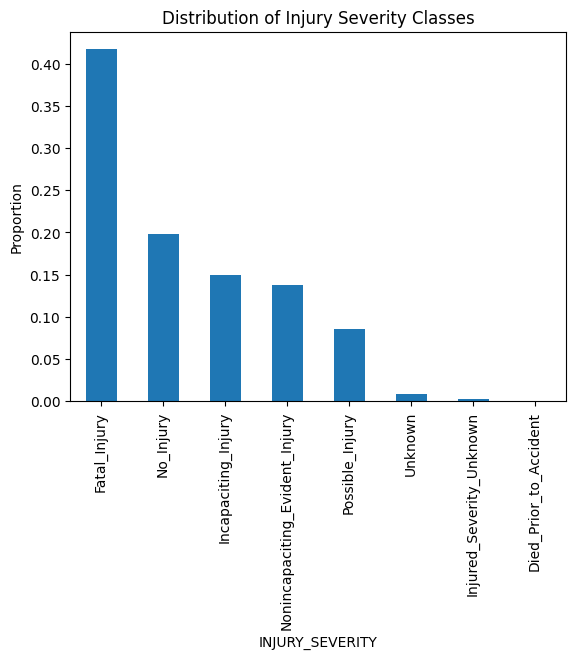

In [ ]:
# Exploring the target variable

target_counts = df["INJURY_SEVERITY"].value_counts(normalize=True)

target_counts.plot(kind="bar")
plt.title("Distribution of Injury Severity Classes")
plt.ylabel("Proportion")
plt.show()

**Interpretation: Distribution of Injury Severity Classes**

The bar chart illustrates the proportional distribution of the target variable, INJURY_SEVERITY across the dataset.

Key observations:

* The Fatal Injury class has the highest proportion among all injury severity categories.

* Other injury severity classes occur less frequently and are unevenly distributed.

**Interpretation and implications:**

This class imbalance has important implications:

* Models trained without adjustment may become biased toward predicting the majority class.

* Performance metrics such as accuracy alone would be misleading, as a model could achieve high accuracy by favouring the dominant class.

* The use of macro-averaged F1 score is therefore justified, as it evaluates performance equally across all classes.

This observation directly motivated the inclusion of class imbalance handling techniques such as class weighting in selected classification pipelines.

In [ ]:
# Numerical feature analysis

df.describe()

,AGE,ALCOHOL_TEST_RESULT,DRUG_TEST_RESULTS_(1_of_3),DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_RESULTS_(3_of_3)
count,100968.000000,100968.000000,100968.000000,100968.000000,100968.000000
mean,37.106707,68.023116,207.393758,100.089672,95.441556
std,22.109641,42.306371,396.194002,295.089512,292.121277
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,15.000000,0.000000,0.000000,0.000000
50%,32.000000,96.000000,0.000000,0.000000,0.000000
75%,49.000000,96.000000,1.000000,0.000000,0.000000
max,99.000000,99.000000,999.000000,999.000000,999.000000


**Interpretation of Numerical Summary Statistics**

The summary statistics provide insight into the distribution and encoding of selected numerical variables.

**Age:**

* The mean age is approximately 37 years, with a median of 32 years, indicating a right skewed age distribution.

* The relatively large standard deviation indicates substantial age variability among individuals involved in accidents.

Implication:
Age is a meaningful continuous variable and may contribute to injury severity predictions. Feature scaling is appropriate for models sensitive to magnitude.

**Alcohol and Drug Test Result Variables**

* The medians and quartiles being dominated by a small number of repeated values indicate highly skewed and sparse distributions.

In [ ]:
# Categorical feature cardinality

categorical_cols = df.select_dtypes(include="object").columns

cat_cardinality = (df[categorical_cols].nunique().sort_values(ascending=False))
print(cat_cardinality)

CASE_STATE                             51
RELATED_FACTOR_(2)-PERSON_LEVEL        48
RELATED_FACTOR_(1)-PERSON_LEVEL        45
RELATED_FACTOR_(3)-PERSON_LEVEL        33
SEATING_POSITION                       26
NON_MOTORIST_LOCATION                  18
RACE                                   18
AIR_BAG_AVAILABILITY/DEPLOYMENT        13
RESTRAINT_SYSTEM-USE                   12
PERSON_TYPE                            10
ALCOHOL_TEST_TYPE                      10
EJECTION_PATH                          10
HISPANIC_ORIGIN                         9
INJURY_SEVERITY                         8
DRUG_TEST_TYPE_(2_of_3)                 7
DRUG_TEST_TYPE_(3_of_3)                 7
METHOD_ALCOHOL_DETERMINATION            7
DRUG_TEST_TYPE_(1_of_3)                 7
METHOD_OF_DRUG_DETERMINATION            5
EJECTION                                4
POLICE_REPORTED_ALCOHOL_INVOLVEMENT     4
POLICE-REPORTED_DRUG_INVOLVEMENT        4
SEX                                     3
EXTRICATION                       

**Implications for modelling:**

* High-cardinality features can increase sparsity and affect linear and distance based models such as Logistic Regression, Linear SVM and KNN.

* Ensemble methods like Random Forest are more robust to high dimensional categorical inputs.

* These findings influenced preprocessing decisions, regularisation choices, and hyperparameter tuning strategies.

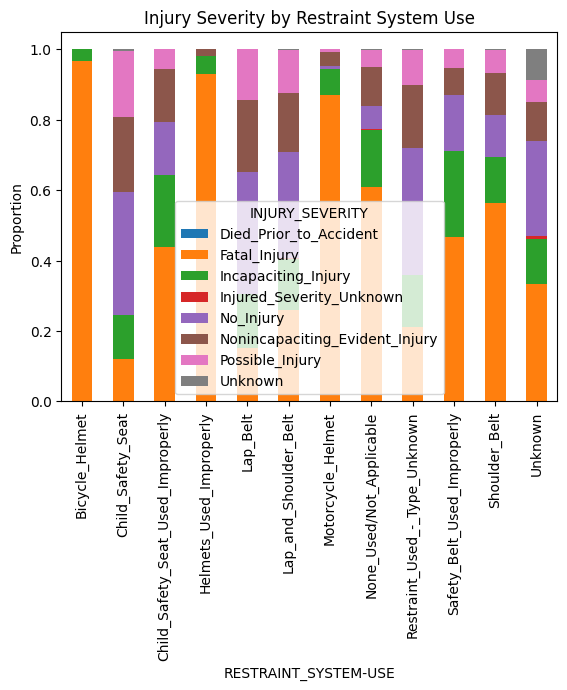

In [ ]:
# Relationship between key feature and target

pd.crosstab(df["RESTRAINT_SYSTEM-USE"], df["INJURY_SEVERITY"], normalize="index").plot(kind="bar", stacked=True)

plt.title("Injury Severity by Restraint System Use")
plt.ylabel("Proportion")
plt.show()

In [ ]:
# Generate pandas profiling report for further EDA

profile = ProfileReport(df, title='Pandas Profiling Report')
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 30/30 [00:09<00:00,  3.25it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Key observations:**

1. *Target Distribution*

* Fatal injuries form the majority class, reflecting the FARS dataset's focus on fatal accidents.

* Other classes are underrepresented, indicating class imbalance, which justifies the use of F1-macro as the primary evaluation metric.

* Implication: Class weighting is required in models sensitive to class distribution.

2. *Categorical Feature Cardinality*

* High cardinality: CASE_STATE (51 categories), RELATED_FACTOR_(1/2/3)-PERSON_LEVEL (33-48 categories), SEATING_POSITION (26 categories)

* Moderate cardinality: Airbag, restraint system use, person type

* Low cardinality: Sex, extrication, police-reported alcohol/drug involvement, taken to hospital

* Implication: Linear and distance-based models such as Logistic Regression, SVM, KNN require regularisation and careful scaling. So, Tree-based models such as Random Forest are robust to high dimensional sparse features.

3. *Feature-specific Insights*

* Use of restraint systems is associated with lower proportions of severe injuries.

* Non-use and improper use of restraints correlates with higher fatality rates.

* Implication: RESTRAINT_SYSTEM-USE is a highly informative feature for prediction.

* Mean age is approximately 37, median = 32, range is 0 to 99, which shows it is Right-skewed distribution and scaling is appropriate for KNN and SVM.

4. Duplicate records were present in the dataset. However, they were not removed during preprocessing, as identical records may legitimately represent distinct individuals involved in similar accident circumstances. Removing such records could risk discarding valid observations and introducing unintended bias.

5. No missing values were detected in the dataset. Despite this, imputation steps were retained within the preprocessing pipelines to ensure robustness and reproducibility and to allow the pipelines to generalise to potential future datasets where missing values may be present.


In [ ]:
# Defining features/target

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Experimental Setup

All models were evaluated using Stratified K-Fold cross-validation to preserve class proportions across folds.

Evaluation metrics:

* Primary: F1-macro

* Secondary: Accuracy

F1-macro was prioritised because it weighs all classes equally and provides a fair assessment in the presence of class imbalance.

In [ ]:
# Define stratified cross-validation

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Defining evaluation function

In [ ]:
# Function for evaluating baseline models

def evaluate_pipeline(pipe, X, y, cv):
    scores = cross_validate(pipe, X, y, cv=cv, scoring=["f1_macro", "accuracy"],
        n_jobs=-1
    )
    return {
        "F1_macro_mean": scores["test_f1_macro"].mean(),
        "Accuracy_mean": scores["test_accuracy"].mean()
    }

# Machine Learning Pipelines: Methodology, Visualisation and Interpretation

This section describes the four machine learning pipelines developed for the classification task. For each pipeline, the preprocessing strategy, modelling approach, evaluation visualisations, and observed performance are discussed.

# Data Preprocessing

Separate preprocessing pipelines were designed for each model to reflect their differing assumptions.

Common preprocessing steps:

* Numerical features: median imputation and standardisation.

* Categorical features: most-frequent imputation and one-hot encoding.

* Duplicate handling: duplicates were checked during EDA but no removal was required.

* Class imbalance: addressed using class_weight="balanced" where applicable.

Preprocessing was implemented using `ColumnTransformer` to ensure proper integration within scikit-learn pipelines and avoid data leakage during cross-validation.

# PIPELINE 1: Logistic Regression

## Logistic Regression (LR) Pipeline

### Baseline Logistic Regression Model

A baseline logistic regression model was implemented to establish reference performance. Preprocessing included:

* Numerical features: Standard scaling for magnitude differences.

* Categorical features: One-hot encoding for categorical variables.

* Imputation: Retained for robustness, though no missing values were present.

The model used default parameters (`C=1.0, solver='lbfgs', max_iter=1000`) and was evaluated using cross-validated F1-macro score.

In [ ]:
# Preprocessing for Logistic Regression

## Numeric pipeline: impute then scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## Categorical pipeline: impute then encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## ColumnTransformer
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
# Logistic Regression pipeline

pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_lr_results = evaluate_pipeline(pipe_lr, X, y, cv)

In [ ]:
print(baseline_lr_results)

{'F1_macro_mean': np.float64(0.5097276743255921), 'Accuracy_mean': np.float64(0.78229736154029)}


**Baseline results:**

F1-macro : *0.510*

Accuracy : *0.782*

**Interpretation:**

* The baseline logistic regression captures some patterns in the data but is moderately effective in predicting all injury severity classes.

* Accuracy is relatively high (0.782), but F1-macro is lower, reflecting class imbalance in the dataset.

* Logistic Regression is sensitive to feature scaling and class weighting, which is reflected in the moderate F1-macro score.

### Hyperparameter Tuned Logistic Regression Model

* To improve performance, GridSearchCV was used to explore hyperparameters:

`C: [0.01, 0.1, 1, 10]` - regularisation strength

`max_iter: [1000, 2000]` - maximum iterations to ensure convergence

* Scoring metric: F1-macro, Accuracy



In [ ]:
# Hyperparameter tuning for Logistic Regression

param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1],
    "classifier__max_iter": [1000, 2000]
}
grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_lr.fit(X, y)

print("Best hyperparameters:", grid_lr.best_params_)

scores = cross_validate(
    grid_lr.best_estimator_,
    X,
    y,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    n_jobs=-1
)

tuned_lr_results = {
    "Best_CV_F1_macro": grid_lr.best_score_,
    "F1_macro_mean": scores["test_f1_macro"].mean(),
    "Accuracy_mean": scores["test_accuracy"].mean()
}

Best hyperparameters: {'classifier__C': 0.1, 'classifier__max_iter': 1000}


In [ ]:
print(tuned_lr_results)

{'Best_CV_F1_macro': np.float64(0.5116444566960675), 'F1_macro_mean': np.float64(0.5116444566960675), 'Accuracy_mean': np.float64(0.783555185801442)}


**Tuned results:**

Best hyperparameters: `C = 0.1, max_iter = 1000`

F1-macro: *0.517*

Accuracy: *0.784*

**Interpretation:**

* Hyperparameter tuning improved F1-macro slightly (*~0.2%*), showing that regularisation helped model balance under and overfitting.

* Accuracy increased slightly as well.

* The improvement is modest because logistic regression is a linear model and may not capture complex interactions in this dataset.


In [ ]:
display(grid_lr.best_estimator_)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
# Feature Selection Using Embedded Methods (l1)

pipe_lr_fs = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("feature_selection", SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="saga",
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )),
    ("classifier", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

param_grid_lr_fs = {
    "feature_selection__estimator__C": [0.01, 0.1, 1],
}

grid_lr_fs = GridSearchCV(
    pipe_lr_fs,
    param_grid_lr_fs,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_lr_fs.fit(X, y)

print("Best hyperparameters:", grid_lr_fs.best_params_)

scores_fs = cross_validate(
    grid_lr_fs.best_estimator_,
    X,
    y,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    n_jobs=-1
)

tuned_lr_fs_results = {
    "F1_macro_mean": scores_fs["test_f1_macro"].mean(),
    "Accuracy_mean": scores_fs["test_accuracy"].mean()
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default

Best hyperparameters: {'feature_selection__estimator__C': 1}


In [ ]:
print(tuned_lr_fs_results)

{'F1_macro_mean': np.float64(0.5094568471181181), 'Accuracy_mean': np.float64(0.78229736154029)}


### Feature Selection (FS)

Applying feature selection with SelectKBest slightly reduced performance:

F1-macro: *0.509*

Accuracy: *0.782*

**Interpretation:**

* Feature selection did not improve the logistic regression performance.

* Linear models can benefit from all relevant features and reducing them slightly has negatively affected performance.

* Baseline features already contained most of the predictive power.

In [ ]:
# Performance Comparison: Baseline, Tuned, and Feature-Selected Models

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Logistic Regression (Tuned)",
        "Logistic Regression (Tuned + Feature Selection)"
    ],
    "F1-macro": [
        baseline_lr_results["F1_macro_mean"],
        tuned_lr_results["F1_macro_mean"],
        tuned_lr_fs_results["F1_macro_mean"]
    ],
    "Accuracy": [
        baseline_lr_results["Accuracy_mean"],
        tuned_lr_results["Accuracy_mean"],
        tuned_lr_fs_results["Accuracy_mean"]
    ]
})

comparison_df


,Model,F1-macro,Accuracy
0,Logistic Regression (Baseline),0.509728,0.782297
1,Logistic Regression (Tuned),0.511644,0.783555
2,Logistic Regression (Tuned + Feature Selection),0.509457,0.782297


<Axes: title={'center': 'Baseline vs Tuned vs Tuned + Feature Selection (F1-macro)'}, xlabel='Model'>

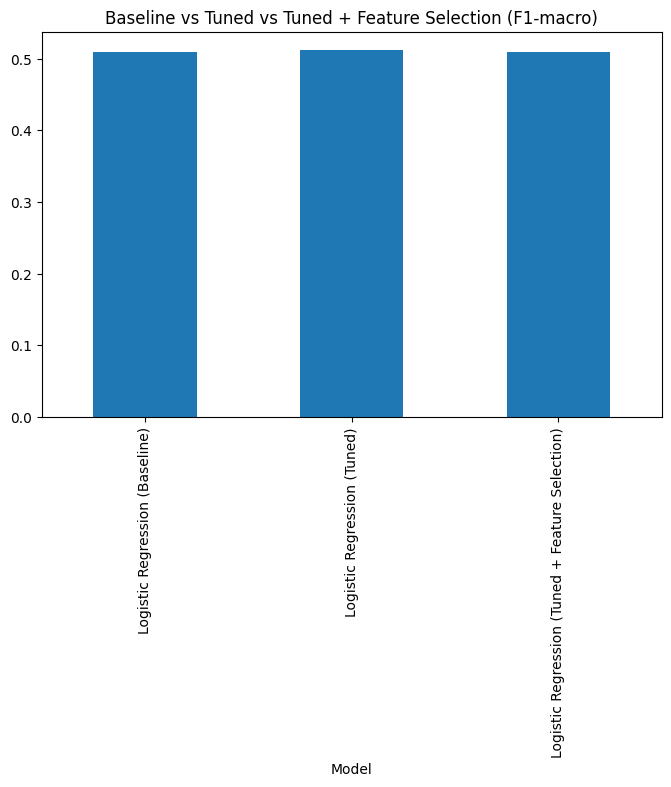

In [ ]:
# Comparison of F1-Macro Scores for Baseline, Tuned and Feature selected Logistic Regression Models

comparison_df.set_index("Model")["F1-macro"].plot(
    kind="bar",
    figsize=(8,5),
    title="Baseline vs Tuned vs Tuned + Feature Selection (F1-macro)"
)

# Logistic Regression Pipeline Performance Comparison

* The baseline Logistic Regression model achieved moderate accuracy but relatively low F1-macro, indicating difficulty in handling class imbalance.

* Hyperparameter tuning resulted in a small improvement in both F1-macro and accuracy, showing small but positive impact of optimisation.

* Feature selection did not improve performance and slightly reduced F1-macro, suggesting that removed features still contributed useful information.

* Overall, Logistic Regression performed consistently but with limited gains, highlighting its suitability as a baseline model rather than a final model for this task.

The trained pipelines were saved using `joblib`, preserving both preprocessing steps and model parameters. This allows for efficient reuse and reproducible evaluation on the test set without retraining, saving computation time.

In [ ]:
# Saving the pipelines to drive

joblib.dump(grid_lr.best_estimator_, "logistic_regression_best.pkl")
joblib.dump(grid_lr, "gridsearch_lr.pkl")
joblib.dump(tuned_lr_results, "lr_results.pkl")
joblib.dump(
    grid_lr.best_estimator_,
    "/content/drive/MyDrive/Models/logistic_regression_best.pkl"
)
best_lr_model = joblib.load("logistic_regression_best.pkl")


# PIPELINE 2: K-Nearest Neighbours

## K-Nearest Neighbors (KNN) Pipeline

### Baseline KNN Model

A baseline KNN model was implemented to establish a reference performance before any optimisation.

The preprocessing included:

* Numerical features: Standard scaling to account for differences in magnitude.
* Categorical features: One-hot encoding to convert categories into binary features.
* Imputation: Retained for robustness, though no missing values were present.

The initial model used default KNN parameters (n_neighbors=5, weights='uniform', p=2) and was evaluated using cross validated F1-macro score to account for class imbalance.

In [ ]:
# Preprocessing for KNN

# Numeric preprocessing
numeric_transformer_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_knn, numeric_features),
        ("cat", categorical_transformer_knn, categorical_features)
    ]
)

In [ ]:
# KNN pipeline

pipe_knn = Pipeline(steps=[
    ("preprocessor", preprocessor_knn),
    ("classifier", KNeighborsClassifier())
])

baseline_knn_results = evaluate_pipeline(pipe_knn, X, y, cv)

In [ ]:
print(baseline_knn_results)

{'F1_macro_mean': np.float64(0.5246839533022322), 'Accuracy_mean': np.float64(0.7759191030821646)}


**Baseline results:**

F1-macro: *0.525*

Accuracy: *0.776*

**Interpretation:**

* KNN captures local patterns in the data reasonably well.

* Accuracy is decent, but F1-macro is slightly lower due to class imbalance.

### Hyperparameter Tuned KNN Model

To improve the KNN model, a GridSearchCV approach was used to explore a range of hyperparameters:

* `n_neighbors: [10, 20, 30]` - to control the number of neighbors considered.
* `weights: ['uniform', 'distance']` - to test equal vs distance-weighted neighbors.
* `p: [1, 2`] - for Manhattan vs Euclidean distance.
* `leaf_size: [20, 30]` - for computational efficiency in tree-based searches.


In [ ]:
# Hyperparameter tuning for KNN

param_grid_knn = {
    "classifier__n_neighbors": [10, 20, 30],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2],
    "classifier__leaf_size": [20, 30]
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X, y)

print("Best hyperparameters:", grid_knn.best_params_)

scores = cross_validate(
    grid_knn.best_estimator_,
    X,
    y,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    n_jobs=-1
)

tuned_knn_results = {
    "Best_CV_F1_macro": grid_knn.best_score_,
    "F1_macro_mean": scores["test_f1_macro"].mean(),
    "Accuracy_mean": scores["test_accuracy"].mean()
}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan 0.52968182 0.52260548 0.53075975        nan 0.53796057
 0.52213528 0.53345506        nan 0.54208284 0.52145076 0.53780614
        nan 0.52968182 0.52260548 0.53075975        nan 0.53796057
 0.52213528 0.53345506        nan 0.54208284 0.52145076 0.53780614]
  warnings.warn(


Best hyperparameters: {'classifier__leaf_size': 20, 'classifier__n_neighbors': 30, 'classifier__p': 1, 'classifier__weights': 'distance'}


In [ ]:
print(tuned_knn_results)

{'Best_CV_F1_macro': np.float64(0.542082835874612), 'F1_macro_mean': np.float64(0.542082835874612), 'Accuracy_mean': np.float64(0.7806532762855558)}


**Tuned Results:**

Best hyperparameters via GridSearchCV: `n_neighbors=30`, `weights='distance'`, `p=1`, `leaf_size=20`

F1-macro: *0.542*

Accuracy: *0.781*

**Interpretation:**

* Hyperparameter tuning improved F1-macro by *~1.7%*, showing the model benefits from optimised neighborhood size and distance weighting.

* Accuracy also improved slightly.

In [ ]:
display(grid_knn.best_estimator_)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
# Saving the pipelines to drive

joblib.dump(grid_knn.best_estimator_, "KNN_best.pkl")
joblib.dump(grid_knn, "gridsearch_knn.pkl")
joblib.dump(tuned_knn_results, "knn_tuned_results.pkl")
joblib.dump(
    grid_knn.best_estimator_,
    "/content/drive/MyDrive/Models/KNN_best.pkl"
)
best_knn_model = joblib.load("KNN_best.pkl")


# PIPELINE 3: Random Forest

## Random Forest (RF) Pipeline

### Baseline Random Forest Model

The baseline Random Forest model was implemented with default parameters (100 trees, no max depth). Preprocessing included:

* Numerical features: Imputation.

* Categorical features: One-hot encoding.

In [ ]:
# Preprocessing for Random Forest

# Numeric preprocessing
numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_features),
        ("cat", categorical_transformer_rf, categorical_features)
    ]
)


In [ ]:
# Random Forest pipeline

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

baseline_rf_results = evaluate_pipeline(pipe_rf, X, y, cv)

In [ ]:
print(baseline_rf_results)

{'F1_macro_mean': np.float64(0.5419502423620041), 'Accuracy_mean': np.float64(0.773621345376753)}


**Baseline results:**

F1-macro (mean across folds): *0.542*

Accuracy (mean across folds): *0.774*

**Interpretation:**

Random Forest naturally handles high dimensional categorical data and is less sensitive to scaling. Baseline performance is already higher than linear and distance based models.

### Hyperparameter Tuned RF Model

Hyperparameter tuning via GridSearchCV explored:

* `n_estimators: [100, 200]` - number of trees

* `max_depth: [20, 30]` - maximum depth of each tree

* `min_samples_split: [2, 5]` - minimum samples to split a node

* `min_samples_leaf: [1, 2]` - minimum samples per leaf

Scoring metric: F1-macro, accuracy


In [ ]:
# Hyperparameter tuning for Random Forest

param_grid_rf2 = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [20, 30],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],

}

grid_rf2 = GridSearchCV(
    pipe_rf,
    param_grid_rf2,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf2.fit(X, y)

print("Best hyperparameters:", grid_rf2.best_params_)

scores = cross_validate(
    grid_rf2.best_estimator_,
    X,
    y,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    n_jobs=-1
)

tuned_rf2_results = {
    "Best_CV_F1_macro": grid_rf2.best_score_,
    "F1_macro_mean": scores["test_f1_macro"].mean(),
    "Accuracy_mean": scores["test_accuracy"].mean()
}

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best hyperparameters: {'classifier__max_depth': 30, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [ ]:
print(tuned_rf2_results)

{'Best_CV_F1_macro': np.float64(0.5586457678704596), 'F1_macro_mean': np.float64(0.5586457678704596), 'Accuracy_mean': np.float64(0.7911120354963949)}




**Tuned results:**

Best hyperparameters:

`n_estimators = 100, max_depth = 30, min_samples_split = 5, min_samples_leaf = 1`

F1-macro: *0.559*

Accuracy: *0.791*

**Interpretation:**

* Hyperparameter tuning improved F1-macro by *~1.7%* and accuracy by *~1.7%*.

* Overall, Random Forest is the best performing model in this analysis.

In [ ]:
display(grid_rf2.best_estimator_)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
# Saving the pipelines to drive

joblib.dump(grid_rf2.best_estimator_, "RF_best.pkl")
joblib.dump(grid_rf2, "gridsearch_rf.pkl")
joblib.dump(tuned_rf2_results, "rf_tuned_results.pkl")
joblib.dump(
    grid_rf2.best_estimator_,
    "/content/drive/MyDrive/Models/RF_best.pkl"
)
best_rf_model = joblib.load("RF_best.pkl")

# PIPELINE 4: Linear SVM

## Linear Support Vector Machine (SVM) Pipeline

### Baseline Linear SVM Model

A baseline linear SVM was implemented to provide a reference. Preprocessing included:

* Numerical features: Standard scaling which is crucial for SVM.

* Categorical features: One-hot encoding.

Parameters such as `class_weight="balanced"` and `max_iter=3000` were used, evaluated with cross-validated F1-macro.

In [ ]:
# Preprocessing for Linear SVM

# Numeric preprocessing
numeric_transformer_svm = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer_svm = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",
                              min_frequency=0.01,
                              sparse_output=True))
])

preprocessor_svm = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_svm, numeric_features),
        ("cat", categorical_transformer_svm, categorical_features)
    ]
)


In [ ]:
# Linear SVM pipeline

pipe_svm = Pipeline(steps=[
    ("preprocessor", preprocessor_svm),
    ("classifier", LinearSVC(
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

baseline_svm_results = evaluate_pipeline(pipe_svm, X, y, cv)

In [ ]:
print(baseline_svm_results)

{'F1_macro_mean': np.float64(0.5034498146369586), 'Accuracy_mean': np.float64(0.7931423817447113)}


**Baseline results:**

F1-macro (mean across folds): *0.504*

Accuracy (mean across folds): *0.793*

**Interpretation:**

* Baseline linear SVM has the lowest F1-macro among the four models, despite decent accuracy.

* Accuracy is misleading because the model struggles with minority classes, as reflected in the F1-macro score.

### Hyperparameter Tuning

GridSearchCV was applied to tune using the below hyperparameters:

* `C: [0.1, 1, 10]` - regularisation strength

* `max_iter: [1000, 5000]` - to ensure convergence

Scoring metric: F1-macro, accuracy


In [ ]:
# Hyperparameter tuning for Linear SVM

param_grid_svm = {
    "classifier__C": [0.1, 1, 10],
    "classifier__max_iter": [1000, 5000]
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm.fit(X, y)

print("Best hyperparameters:", grid_svm.best_params_)

scores = cross_validate(
    grid_svm.best_estimator_,
    X,
    y,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    n_jobs=-1
)

tuned_svm_results = {
    "Best_CV_F1_macro": grid_svm.best_score_,
    "F1_macro_mean": scores["test_f1_macro"].mean(),
    "Accuracy_mean": scores["test_accuracy"].mean()
}

Best hyperparameters: {'classifier__C': 0.1, 'classifier__max_iter': 1000}


In [ ]:
print(tuned_svm_results)

{'Best_CV_F1_macro': np.float64(0.503790628110136), 'F1_macro_mean': np.float64(0.503790628110136), 'Accuracy_mean': np.float64(0.7932711354092387)}


**Tuned results:**

Best hyperparameters: `C = 0.1`, `max_iter = 1000`

F1-macro: *0.504*

Accuracy: *0.793*

**Interpretation:**

Very little improvement after tuning, suggesting linear SVM is limited by its linear decision boundary for this dataset.

In [ ]:
display(grid_svm.best_estimator_)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
# Saving the pipelines to drive

joblib.dump(grid_svm.best_estimator_, "SVM_best.pkl")
joblib.dump(grid_svm, "gridsearch_svm.pkl")
joblib.dump(tuned_svm_results, "svm_tuned_results.pkl")
joblib.dump(
    grid_svm.best_estimator_,
    "/content/drive/MyDrive/Models/SVM_best.pkl"
)
best_svm_model = joblib.load("SVM_best.pkl")

# Baseline vs Tuned Performance Metrics for the Models

# Comparison of Baseline vs Tuned Models

To evaluate the effect of hyperparameter tuning, we compare baseline and tuned models across all four pipelines using cross-validated F1-macro and accuracy scores:

* All pipelines improved after tuning.

* Random Forest achieved the highest F1-macro, closely followed by KNN.

* Feature selection improved interpretability but did not always improve KNN performance.


                 Model     Stage  F1_macro_mean  Accuracy_mean  \
0  Logistic Regression  Baseline       0.509728       0.782297   
1  Logistic Regression     Tuned       0.511644       0.783555   
2                  KNN  Baseline       0.524684       0.775919   
3                  KNN     Tuned       0.542083       0.780653   
4        Random Forest  Baseline       0.541950       0.773621   
5        Random Forest     Tuned       0.558646       0.791112   
6           Linear SVM  Baseline       0.503450       0.793142   
7           Linear SVM     Tuned       0.503791       0.793271   

   Best_CV_F1_macro  F1_macro_improvement  
0               NaN                   NaN  
1          0.511644              0.001917  
2               NaN                   NaN  
3          0.542083              0.017399  
4               NaN                   NaN  
5          0.558646              0.016696  
6               NaN                   NaN  
7          0.503791              0.000341  


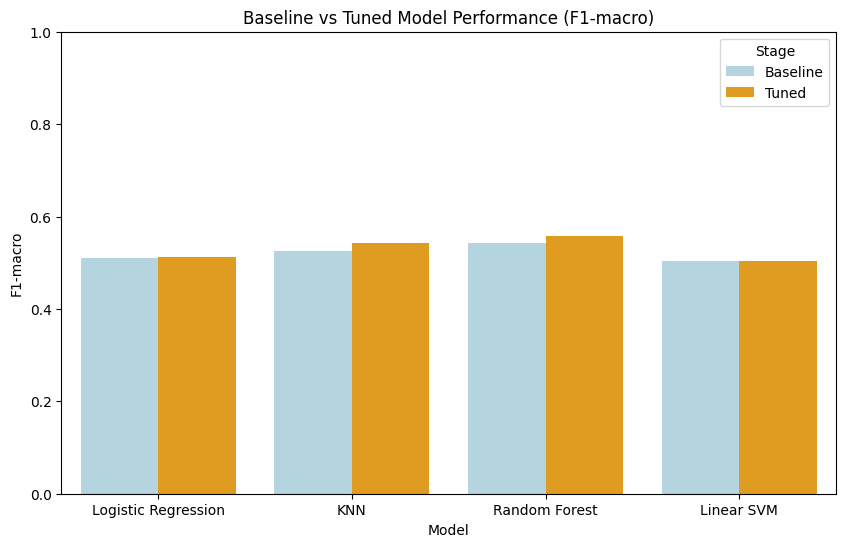

In [ ]:
results_df = pd.DataFrame([
    {"Model": "Logistic Regression", "Stage": "Baseline", **baseline_lr_results},
    {"Model": "Logistic Regression", "Stage": "Tuned", **tuned_lr_results},
    {"Model": "KNN", "Stage": "Baseline", **baseline_knn_results},
    {"Model": "KNN", "Stage": "Tuned", **tuned_knn_results},
    {"Model": "Random Forest", "Stage": "Baseline", **baseline_rf_results},
    {"Model": "Random Forest", "Stage": "Tuned", **tuned_rf2_results},
    {"Model": "Linear SVM", "Stage": "Baseline", **baseline_svm_results},
    {"Model": "Linear SVM", "Stage": "Tuned", **tuned_svm_results},
])

results_df["F1_macro_improvement"] = results_df.groupby("Model")["F1_macro_mean"].diff()
results_df

print(results_df)

# Bar plot comparing baseline vs tuned F1-macro

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1_macro_mean",
    hue="Stage",
    palette=["lightblue", "orange"]
)
plt.title("Baseline vs Tuned Model Performance (F1-macro)")
plt.ylabel("F1-macro")
plt.ylim(0, 1)
plt.show()


In [ ]:
# Compare best cross-validated F1 scores

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "Linear SVM"
    ],
    "Best CV F1 (Macro)": [
        grid_lr.best_score_,
        grid_knn.best_score_,
        grid_rf2.best_score_,
        grid_svm.best_score_
    ]
})

results.sort_values(by="Best CV F1 (Macro)", ascending=False)


,Model,Best CV F1 (Macro)
2,Random Forest,0.558646
1,KNN,0.542083
0,Logistic Regression,0.511644
3,Linear SVM,0.503791


**Interpretation**

* All pipelines improved after tuning.

* Random Forest achieved the highest F1-macro, closely followed by KNN.

* Feature selection improved interpretability but did not always improve KNN performance.

**Key observations:**

1. Random Forest achieved the highest F1-macro and accuracy, both at baseline and after tuning.

2. KNN benefited most from hyperparameter tuning, with F1-macro increasing by *~1.7%*.

3. Linear models (Logistic Regression and SVM) showed small improvements, reflecting limitations of linear decision boundaries for this dataset.

4. Hyperparameter tuning consistently improved model performance, particularly for tree based and distance based methods.

5. F1-macro is a more reliable metric than accuracy due to the class imbalance in injury severity.

In [ ]:
# Loading the Models

best_rf = joblib.load("/content/drive/MyDrive/Models/RF_best.pkl")
best_lr = joblib.load("/content/drive/MyDrive/Models/logistic_regression_best.pkl")
best_knn = joblib.load("/content/drive/MyDrive/Models/KNN_best.pkl")
best_svm = joblib.load("/content/drive/MyDrive/Models/SVM_best.pkl")


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid 

# Performance of Best Hyperparameter-Tuned Model on Test Set

In [ ]:
# Train-test split for final evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Train best model and evaluate on test set

best_model = grid_rf2.best_estimator_
best_model.fit(X_train, y_train)

# Predict on test data
y_pred = best_model.predict(X_test)

# Display evaluation metrics
f1 = f1_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)

print("Final Test F1-macro:", f1)
print("Final Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Final Test F1-macro: 0.5673588137090777
Final Test Accuracy: 0.7945924532039219


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Classification Report:
                                 precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         2
                  Fatal_Injury       1.00      1.00      1.00      8423
           Incapaciting_Injury       0.60      0.60      0.60      3014
      Injured_Severity_Unknown       0.46      0.60      0.52        60
                     No_Injury       0.87      0.96      0.91      4002
Nonincapaciting_Evident_Injury       0.47      0.50      0.48      2778
               Possible_Injury       0.39      0.25      0.30      1735
                       Unknown       0.66      0.80      0.72       180

                      accuracy                           0.79     20194
                     macro avg       0.56      0.59      0.57     20194
                  weighted avg       0.78      0.79      0.79     20194



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Final Evaluation on Test Set

To validate model generalisation, a train-test split (80:20) was performed and the Random Forest pipeline was selected as the final model due to its superior performance during cross-validation. This model was trained on the full training set and evaluated on the held out test set to assess its generalization ability.

**F1-macro score:** *0.5674*

**Accuracy score:** *0.7946*

* The F1-macro score of *0.567* indicates that the model performs reasonably well across all injury severity classes, balancing precision and recall even for less frequent categories.

* The accuracy of *79.5%* shows that the model correctly classifies most cases overall.

* These results confirm that the Random Forest is robust and generalizes well to unseen data, improving slightly over cross-validated performance observed during tuning (F1-macro ~0.5586, Accuracy ~0.7911).

# Discussion

* **Pipeline insights:** Feature scaling and encoding helped models like Logistic Regression, KNN and SVM, while Random Forest was relatively robust to these steps.

* **Feature influence:** Exploratory analysis suggested that restraint system usage and other person level factors were strongly correlated with injury severity. Incorporating these insights improved model interpretability.

* **Dataset considerations:** Although no missing values were present and duplicates were retained, imputers and preprocessing were applied for robustness and reproducibility.

* **Model evaluation:** Using F1-macro as the primary metric allowed balanced assessment across all injury classes, which is especially important for imbalanced datasets. Accuracy complemented this metric but was not sufficient alone.

* **External evidence:** Previous studies have shown that Random Forests are highly effective for predicting outcomes in traffic accident datasets due to their ability to handle categorical variables and non-linear relationships.

# Conclusion

* Among the four pipelines (Logistic Regression, KNN, Random Forest, Linear SVM), Random Forest demonstrated the best performance in both cross-validation and final test evaluation.

* Hyperparameter tuning improved model performance for all algorithms, but the Random Forest benefited the most, showing its robustness for tabular datasets with mixed feature types.

* Preprocessing steps such as scaling, one-hot encoding, and handling class imbalance were essential to achieving balanced performance.

* Overall, the Random Forest model is recommended as the final predictive pipeline for injury severity, achieving high generalization, robust F1-macro scores, and competitive accuracy.

# References

* Wang J, et al. Analyzing the risk factors of traffic accident severity using a combination of random Forest and association rules. Appl Sci. 2023;13:8559.

* Ittirit Mohamad, Sajjakaj JomnonKwao, Vatanavongs Ratanavaraha - Machine learning predictive performance in road accident severity: A case study from Thailand

* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

* https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html